In [24]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import os

from PIL import Image
from transformers import AutoProcessor, Blip2Processor, Blip2ForImageTextRetrieval,  Blip2ForConditionalGeneration, BitsAndBytesConfig
from sklearn.metrics import confusion_matrix,  classification_report, ConfusionMatrixDisplay, mutual_info_score
from translate_dn_en import translate_danish_to_english

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [26]:
# load Blip-2 model and processor
processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-flan-t5-xl")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [27]:
# load danish data and translate to english
df = pd.read_csv("metadata.csv") # make sure it matches name of csv
unique_categories = df["Category"].dropna().unique() # drop rows with missing values

# translation map
category_to_en = {
    cat : translate_danish_to_english(cat)
    for cat in unique_categories
}
df["Category"] = df["Category"].map(category_to_en)

# save to a new csv
df.to_csv("metadata_en.csv", index=False)

In [28]:
df = pd.read_csv("metadata_en.csv") # load english data
df = df.dropna(subset=["Image File", "Category"]) # drop rows with missing values (NaN)

# use the first 25, can be changed for other subsets
df = df[:25]
true_labels = list(df["Category"])
categories = list(df["Category"].unique())

image_paths = [
    os.path.join("images2", fname) # change images2 to name of folder with images
    for fname in df["Image File"]
]

In [29]:
# Get Blip-2 to do classification by giving it a prompt
prompt = f"Given an image, output ONLY ONE Category from this list: {categories}. "
prompt

"Given an image, output ONLY ONE Category from this list: ['Recreation & Garden', 'Lamps', 'Electronics', 'Housing', 'Music & Books', 'Missing category', 'Kitchen stuff', 'Toys', 'Bicycles', 'Furniture']. "

In [30]:
# image classification function
def classify_image(image_path: str, prompt: str):
    """
    Classify a single image by prompting BLIP-2 to choose one category from a fixed list.
    """
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, text=prompt, return_tensors="pt", padding=True)
    
    generated_ids = model.generate(  
        **inputs,
        max_new_tokens=10,
        do_sample=False
    )

    prediction = processor.decode(
        generated_ids[0], skip_special_tokens=True
    )
    return prediction

In [31]:
correct = 0
y_true = []
y_pred = []

for img_path, gt in zip(image_paths, true_labels):
    pred = classify_image(img_path, prompt)
    is_correct = pred == gt
    
    y_true.append(gt)
    y_pred.append(pred)
    
    if is_correct:
        correct += 1

accuracy = correct / len(image_paths)
print("Accuracy:", accuracy)

Accuracy: 0.44


In [32]:
for i in range(10):
    print(
        "GT:", y_true[i],
        "| Pred:", y_pred[i],
    )

GT: Recreation & Garden | Pred: Toys
GT: Lamps | Pred: Lamps
GT: Electronics | Pred: Electronics
GT: Recreation & Garden | Pred: Toys
GT: Housing | Pred: Furniture
GT: Housing | Pred: Furniture
GT: Recreation & Garden | Pred: Missing category
GT: Music & Books | Pred: Music & Books
GT: Lamps | Pred: Lamps
GT: Music & Books | Pred: Music & Books


In [33]:
df_blip2 = pd.DataFrame({
    "image_file": image_paths,
    "true_label": true_labels,
    "blip2_pred": y_pred
})

df_blip2.to_csv("blip2_predictions.csv", index=False)

In [34]:
categories = sorted(set(y_true + y_pred))

# confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=categories
)

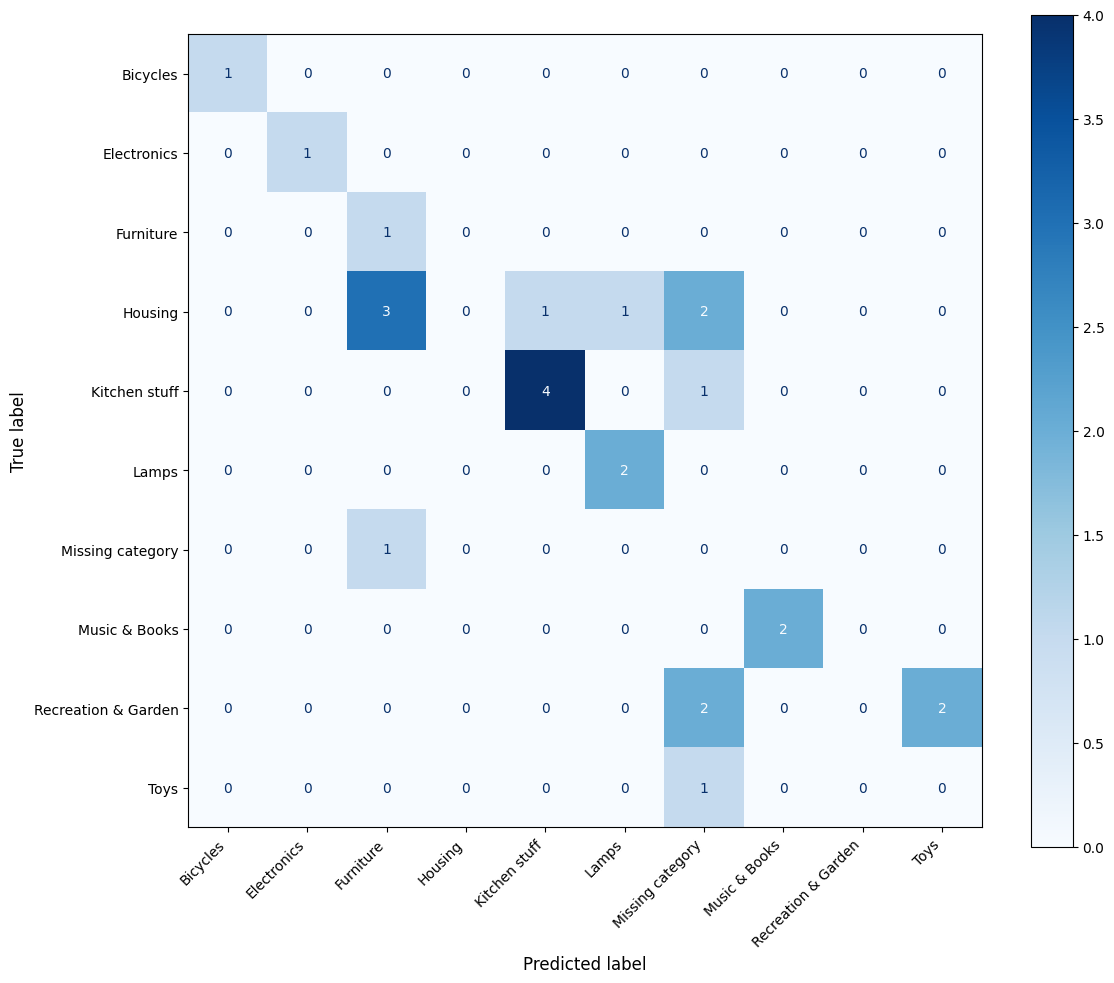

In [36]:
# plot confusion matrix (made bigger than default)
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categories
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    xticks_rotation=45
)

# fix label alignment
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.xticks(ha="right")  
plt.yticks(rotation=0)  

# plot
plt.tight_layout()
plt.show()

In [37]:
# print classification report
print(
    classification_report(
        y_true,
        y_pred,
        labels=categories
    )
)

                     precision    recall  f1-score   support

           Bicycles       1.00      1.00      1.00         1
        Electronics       1.00      1.00      1.00         1
          Furniture       0.20      1.00      0.33         1
            Housing       0.00      0.00      0.00         7
      Kitchen stuff       0.80      0.80      0.80         5
              Lamps       0.67      1.00      0.80         2
   Missing category       0.00      0.00      0.00         1
      Music & Books       1.00      1.00      1.00         2
Recreation & Garden       0.00      0.00      0.00         4
               Toys       0.00      0.00      0.00         1

           accuracy                           0.44        25
          macro avg       0.47      0.58      0.49        25
       weighted avg       0.38      0.44      0.40        25



C:\Users\Sandra\PycharmProjects\ProductLifetime\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sandra\PycharmProjects\ProductLifetime\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sandra\PycharmProjects\ProductLifetime\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [38]:
print(
    mutual_info_score(labels_true=y_true, labels_pred=y_pred)
)

1.3337877375023153
